## 6 Classifier Evaluation

This notebook evaluates our trained classifier.

In [1]:
import sys
import os
from pathlib import Path
import torch
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
import pandas as pd
from transformers import WhisperProcessor, WhisperForConditionalGeneration

notebook_dir = Path.cwd()
whisper_dir = notebook_dir.parent
sys.path.append(str(whisper_dir))

from whisper_asr import load_all_data, extract_decoder_embeddings
from whisper_asr.utils import get_best_gpu

os.environ["TOKENIZERS_PARALLELISM"] = "false"
DEVICE = torch.device(f"cuda:{get_best_gpu()}" if torch.cuda.is_available() else "cpu")
print(f"Using device: {DEVICE}")

/local/scratch/matuor/whisper/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Selected GPU 7 with 24121 MiB free memory
Using device: cuda:7


In [2]:
MODEL_PATH = "../models/whisper-medium-rm-all-it"
processor = WhisperProcessor.from_pretrained(MODEL_PATH)
model = WhisperForConditionalGeneration.from_pretrained(MODEL_PATH).to(DEVICE)
print("Model loaded.")
test_df = load_all_data("test")
test_labels = test_df["idiom"].tolist()

Loading weights: 100%|██████████| 947/947 [00:00<00:00, 4771.60it/s]


Model loaded.


Extracting decoder embeddings: 100%|██████████| 79/79 [01:16<00:00,  1.03it/s]

Absolute counts:
Predicted idiom  Puter  RG  Surmiran  Sursilvan  Sutsilvan  Vallader
True idiom                                                          
Puter              112   0         0          0          0         2
RG                   0  80         0          1          0         0
Surmiran             0   0       151          0          0         0
Sursilvan            0   0         0         94          0         0
Sutsilvan            0   0         0          0         94         0
Vallader             1   0         1          0          0        95

Normalized (by true idiom):
Predicted idiom  Puter     RG  Surmiran  Sursilvan  Sutsilvan  Vallader
True idiom                                                             
Puter            0.982  0.000      0.00      0.000        0.0     0.018
RG               0.000  0.988      0.00      0.012        0.0     0.000
Surmiran         0.000  0.000      1.00      0.000        0.0     0.000
Sursilvan        0.000  0.000      0.00   

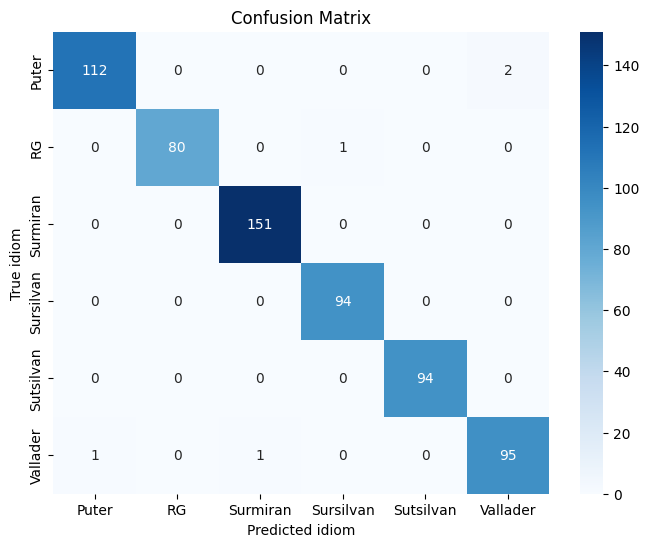

In [3]:
classifier = joblib.load("../models/idiom_classifier.pkl")
test_embeddings = extract_decoder_embeddings(
    model, processor,
    test_df["audio_path"].tolist(),
    test_df["sentence"].tolist(),
    device=DEVICE, batch_size=8
)
predictions = classifier.predict(test_embeddings)
cm = confusion_matrix(test_labels, predictions, labels=classifier.classes_)

# Convert to DataFrame for readability
cm_df = pd.DataFrame(cm, index=classifier.classes_, columns=classifier.classes_)
cm_df.index.name = "True idiom"
cm_df.columns.name = "Predicted idiom"

print("Absolute counts:")
print(cm_df)

# Normalized by row (true idiom) → percentages
cm_norm = cm_df.div(cm_df.sum(axis=1), axis=0).round(3)
print("\nNormalized (by true idiom):")
print(cm_norm)

# Optional heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(cm_df, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.show()

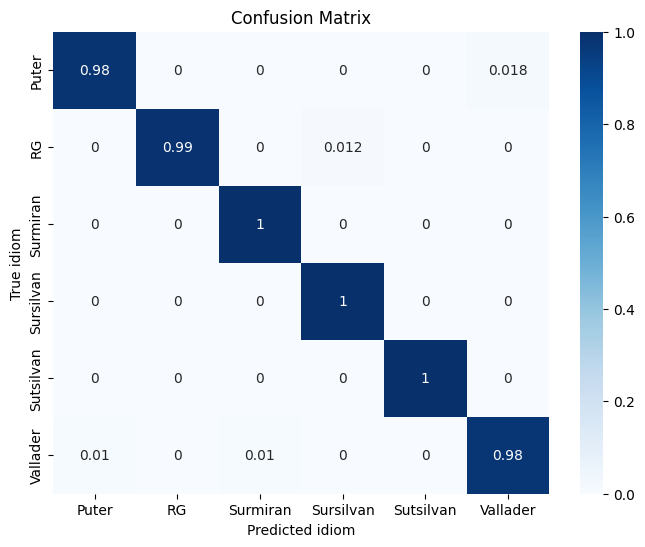

In [4]:
plt.figure(figsize=(8, 6))
sns.heatmap(cm_norm, annot=True, cmap='Blues')
plt.title('Confusion Matrix')
plt.show()

In [5]:
import numpy as np

# Get coefficients for each class (shape: n_classes x 1024)
coefs = classifier.coef_  # if logistic regression; if svm, use support vector information
class_names = classifier.classes_

# For each idiom, show the top 5 features by absolute weight
print("Top features for each idiom (by absolute coefficient):\n")
for i, idiom in enumerate(class_names):
    weights = coefs[i]
    top_indices = np.argsort(-np.abs(weights))[:5]   # descending
    print(f"{idiom}:")
    for rank, idx in enumerate(top_indices, start=1):
        print(f"  {rank}. Feature {idx:4d}   weight = {weights[idx]:+.4f}")
    print()

Top features for each idiom (by absolute coefficient):

Puter:
  1. Feature  975   weight = -0.3262
  2. Feature  872   weight = +0.3211
  3. Feature  264   weight = -0.3207
  4. Feature  270   weight = +0.3189
  5. Feature  426   weight = +0.3185

RG:
  1. Feature  245   weight = -0.1863
  2. Feature  679   weight = -0.1692
  3. Feature  234   weight = -0.1629
  4. Feature  560   weight = +0.1599
  5. Feature  377   weight = +0.1514

Surmiran:
  1. Feature  961   weight = +0.1984
  2. Feature  333   weight = +0.1777
  3. Feature  261   weight = -0.1525
  4. Feature  972   weight = +0.1511
  5. Feature  364   weight = -0.1470

Sursilvan:
  1. Feature   39   weight = -0.1765
  2. Feature  155   weight = +0.1639
  3. Feature  336   weight = +0.1627
  4. Feature  297   weight = -0.1609
  5. Feature  830   weight = +0.1527

Sutsilvan:
  1. Feature  393   weight = +0.1856
  2. Feature  908   weight = -0.0670
  3. Feature  565   weight = -0.0648
  4. Feature  535   weight = +0.0643
  5. Feat

Running t‑SNE...
[t-SNE] Computing 91 nearest neighbors...
[t-SNE] Indexed 631 samples in 0.001s...
[t-SNE] Computed neighbors for 631 samples in 0.543s...
[t-SNE] Computed conditional probabilities for sample 631 / 631
[t-SNE] Mean sigma: 24.864438
[t-SNE] KL divergence after 250 iterations with early exaggeration: 60.939182
[t-SNE] KL divergence after 1000 iterations: 0.602771


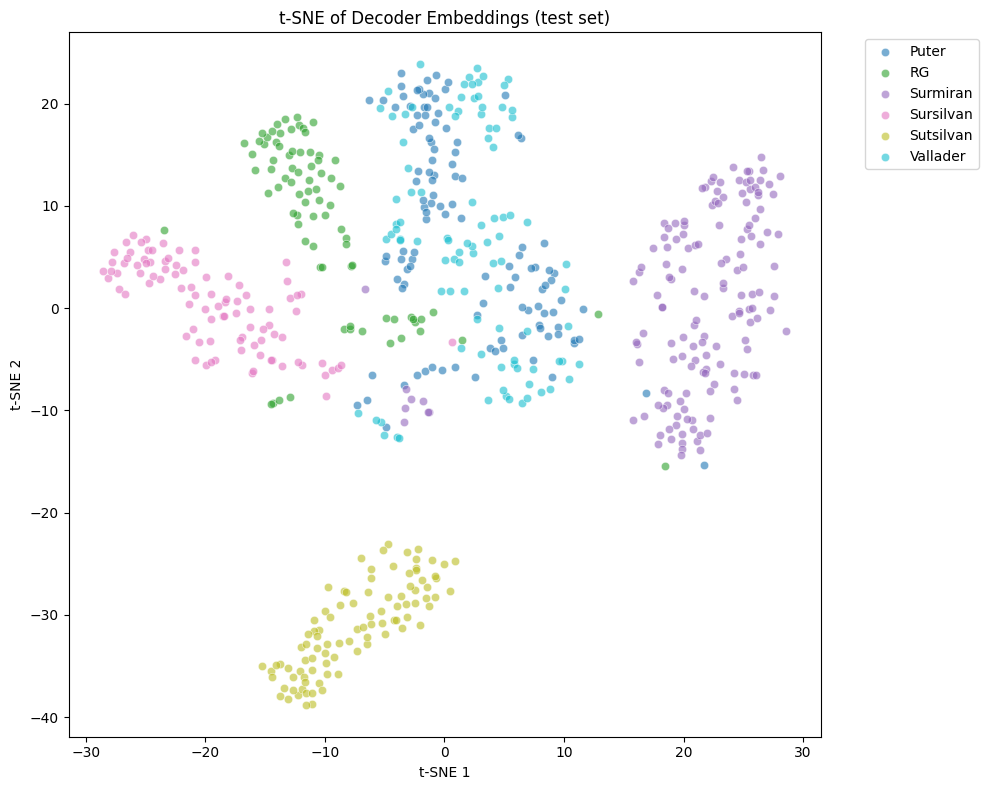

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE

# If you have both train and test embeddings, you can combine them:
# all_embeddings = np.concatenate([train_embeddings, test_embeddings], axis=0)
# all_labels = np.array(train_labels + test_labels)
# But for a quick view, use the test set:
embeddings = test_embeddings
labels = np.array(test_labels)

# t‑SNE can be slow on large datasets; if you have >5000 samples, consider sampling
if len(embeddings) > 5000:
    np.random.seed(42)
    indices = np.random.choice(len(embeddings), size=5000, replace=False)
    embeddings = embeddings[indices]
    labels = labels[indices]

# Reduce to 2 dimensions
print("Running t‑SNE...")
tsne = TSNE(n_components=2, random_state=42, perplexity=30, verbose=1)
emb_2d = tsne.fit_transform(embeddings)

# Plot
plt.figure(figsize=(10, 8))
unique_idioms = np.unique(labels)
colors = plt.cm.tab10(np.linspace(0, 1, len(unique_idioms)))

for idiom, color in zip(unique_idioms, colors):
    mask = labels == idiom
    plt.scatter(emb_2d[mask, 0], emb_2d[mask, 1], c=[color], label=idiom, alpha=0.6, edgecolors='w', linewidth=0.5)

plt.title("t‑SNE of Decoder Embeddings (test set)")
plt.xlabel("t‑SNE 1")
plt.ylabel("t‑SNE 2")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()